#### Стеганография аудио и видео информации. Лабораторная работа №4
|   Группа          |   ФИО             |   
|   :------------:  |   :------------:  |
|   М092501(71)     |   Шарибжанов И.Т. |

**Цель работы:**
Изучение метода скрытия данных в пространственной области методом замены наименее значащего бита, получение навыков реализации изученного метода в программной среде

In [ ]:
%pip install Pillow numpy qrcode opencv-python matplotlib

##### Импорт библиотек и вспомогательные функции

In [8]:
from PIL import Image
import numpy as np
import qrcode
import cv2
import matplotlib.pyplot as plt

def int_to_bits(number, bit_length=16):
    """Перевод целого числа в битовую строку фиксированной длины"""
    return format(number, f'0{bit_length}b')

def bits_to_int(bits):
    """Перевод битовой строки обратно в целое число"""
    return int(bits, 2)

def show_image(image_path, title):
    """Вспомогательная функция для вывода картинки"""
    img = Image.open(image_path)
    plt.figure(figsize=(3, 3))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

##### Генерация и Чтение QR-кода

In [9]:
def generate_qr(text, output_qr_path):
    """Формирует QR-код из текста, сохраняет его и возвращает массив битов и размеры"""
    qr = qrcode.QRCode(version=1, error_correction=qrcode.constants.ERROR_CORRECT_L, box_size=1, border=1)
    qr.add_data(text)
    qr.make(fit=True)
    
    # Создаем черно-белое изображение (1-бит)
    qr_img = qr.make_image(fill_color="black", back_color="white").convert('1')
    qr_img.save(output_qr_path)
    
    # Преобразуем в массив нулей и единиц
    qr_arr = np.array(qr_img, dtype=int)
    h, w = qr_arr.shape
    qr_bits = ''.join(str(bit) for bit in qr_arr.flatten())
    
    print(f"Сгенерирован QR-код размером {w}x{h}. Сохранен как: {output_qr_path}")
    return qr_bits, w, h

def read_qr(qr_image_path):
    """Считывает QR-код из графического файла и возвращает текст"""
    img_cv2 = cv2.imread(qr_image_path)
    detector = cv2.QRCodeDetector()
    data, bbox, straight_qrcode = detector.detectAndDecode(img_cv2)
    
    if data:
        return data
    else:
        raise ValueError("Не удалось распознать QR-код. Возможно, изображение повреждено или не содержит QR-код")

##### Функция встраивания (Кодер)

In [10]:
def embed_lsb(image_path, payload_bits, w, h, output_stego_path):
    """Встраивает биты данных и их размеры в изображение методом НЗБ"""
    # Формируем заголовок (32 бита: 16 на ширину, 16 на высоту)
    header_bits = int_to_bits(w, 16) + int_to_bits(h, 16)
    full_bits = header_bits + payload_bits
    
    img = Image.open(image_path)
    img_arr = np.array(img)
    flat_img = img_arr.flatten()
    
    if len(full_bits) > len(flat_img):
        raise ValueError("Ошибка: Объем данных превышает емкость контейнера!")
        
    for i in range(len(full_bits)):
        flat_img[i] = (flat_img[i] & 254) | int(full_bits[i])
        
    stego_img_arr = flat_img.reshape(img_arr.shape)
    stego_img = Image.fromarray(stego_img_arr)
    stego_img.save(output_stego_path, format='BMP')
    print(f"Данные встроены в контейнер. Сохранено как: {output_stego_path}")

##### Функция извлечения (Декодер)

In [11]:
def extract_lsb(stego_image_path, output_qr_path):
    """Извлекает биты из контейнера, восстанавливает картинку (QR) и сохраняет ее."""
    img = Image.open(stego_image_path)
    flat_img = np.array(img).flatten()
    
    # Читаем размеры (первые 32 бита)
    w = bits_to_int(''.join(str(flat_img[i] & 1) for i in range(16)))
    h = bits_to_int(''.join(str(flat_img[i] & 1) for i in range(16, 32)))
    
    # Читаем сами данные
    payload_length = w * h
    payload_bits = ''.join(str(flat_img[i] & 1) for i in range(32, 32 + payload_length))
    
    # Собираем изображение обратно
    qr_arr = np.array([int(b) for b in payload_bits], dtype=np.uint8).reshape((h, w))
    qr_img = Image.fromarray(qr_arr * 255, mode='L')
    
    # Масштабируем для уверенного чтения OpenCV
    qr_img_scaled = qr_img.resize((w * 10, h * 10), Image.NEAREST)
    qr_img_scaled.save(output_qr_path)
    
    print(f"Изображение извлечено из контейнера. Сохранено как: {output_qr_path}")

##### Запуск и выполнение программы

--- ЭТАП 1: ПОДГОТОВКА И ВСТРАИВАНИЕ ---
Сгенерирован QR-код размером 27x27. Сохранен как: original_qr.png


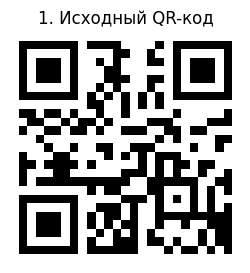

Данные встроены в контейнер. Сохранено как: B.bmp

--- ЭТАП 2: ИЗВЛЕЧЕНИЕ И ДЕКОДИРОВАНИЕ ---
Изображение извлечено из контейнера. Сохранено как: extracted_qr.png


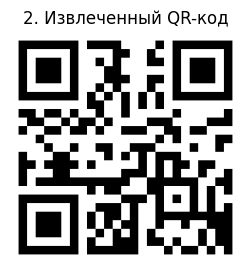


Извлеченный текст: 'Шарибжанов'
Текст успешно сохранен в файл: A.txt


In [12]:
# --- Настройки файлов ---
secret_text = "Шарибжанов"          # Текст для скрытия
original_qr = "original_qr.png"     # Исходный QR-код
input_image = "A.bmp"               # Пустой контейнер
stego_image = "B.bmp"               # Контейнер со скрытыми данными
extracted_qr = "extracted_qr.png"   # Восстановленный из пикселей QR-код
output_text_file = "A.txt"          # Финальный текстовый файл с расшифровкой

print("--- ЭТАП 1: ПОДГОТОВКА И ВСТРАИВАНИЕ ---")
# 1. Генерируем QR-код
qr_bits, width, height = generate_qr(secret_text, original_qr)
show_image(original_qr, "1. Исходный QR-код")

# 2. Встраиваем данные в изображение
embed_lsb(input_image, qr_bits, width, height, stego_image)


print("\n--- ЭТАП 2: ИЗВЛЕЧЕНИЕ И ДЕКОДИРОВАНИЕ ---")
# 3. Извлекаем данные (собираем извлеченный QR-код)
extract_lsb(stego_image, extracted_qr)
show_image(extracted_qr, "2. Извлеченный QR-код")

# 4. Читаем извлеченный QR-код
decrypted_text = read_qr(extracted_qr)
print(f"\nИзвлеченный текст: '{decrypted_text}'")

# 5. Сохраняем финальный текст в файл
with open(output_text_file, 'w', encoding='utf-8') as file:
    file.write(decrypted_text)
print(f"Текст успешно сохранен в файл: {output_text_file}")